# Práctica 1. Niveles Lingüísticos.
### Lingüística Computacional 2026-2
#### Cuerpo Académico
**Dra.** María Ximena Gutiérrez Vasques

**Ayud.** Ximena de la Luz Contreras Mendoza

**Lab.** Diego Alberto Barriga Martínez

#### Alumno
Toporek Coca Eric - **314284987**

## 1 Fonética


Podemos observar que, en el sistema de búsqueda del notebook 1, al ingresar un término no existente dentro del diccionario de un lenguaje, solo obtendremos la cadena vacía. Para poder aproximar la bibblioteca de python `difflib` que sirve para hacer comparaciones en secuencias[^1], en particular vamos a utilizar la función `get_close_matches` con el término deseado, el diccionario del lenguaje (dataset) y un radio de similitud (que por defecto es del 60%), esta función será utilizada dentro de `get_ipa_transcriptions`, por lo que, tomando el notebook del laboratio tenemos:

[^1] Documentación de la biblioteca `difflib` [link](https://docs.python.org/3/library/difflib.html)

In [54]:
import http
from collections import defaultdict, Counter

import pandas as pd
import requests as r

from rich import print as rprint
from rich.columns import Columns
from rich.panel import Panel
from rich.text import Text

from difflib import get_close_matches

import re
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import cess_esp

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn_crfsuite import CRF
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



In [3]:
def download_ipa_corpus(iso_lang: str) -> str:
    """Get ipa-dict file from Github

    Parameters:
    -----------
    iso_lang:
        Language as iso code

    Results:
    --------
    dict:
        Dictionary with words as keys and phonetic representation
        as values for a given lang code
    """
    print(f"Downloading {iso_lang}", end="::")
    response = r.get(IPA_URL.format(lang=iso_lang))
    status_code = response.status_code
    print(f"status={status_code}")
    if status_code != http.HTTPStatus.OK:
        print(f"ERROR on {iso_lang} :(")
        return ""
    return response.text

In [4]:
def parse_response(response: str) -> dict:
    """Parse text response from ipa-dict to python dict

    Each row have the format:
    [WORD][TAB]/[IPA]/(, /[IPA]/)?

    Parameters
    ----------
    response: str
        ipa-dict raw text

    Returns
    -------
    dict:
        A dictionary with the word as key and the phonetic
        representations as value
    """
    ipa_list = response.rstrip().split("\n")
    result = {}
    for item in ipa_list:
        if item == '':
            continue
        item_list = item.split("\t")
        result[item_list[0]] = item_list[1]
    return result

In [13]:
def get_ipa_transcriptions(word: str, dataset: dict) -> list[str]:
    """Search for a word in an IPA phonetics dict, with fallback approximations
    
    Given a word this function returns the IPA transcriptions.
    If the word is not found, it tries to find the closest match.
    """
    word_lower = word.lower()
    
    # 1. Check if the exact word exists in the dataset
    if word_lower in dataset:
        return dataset[word_lower].split(", ")
    
    # 2. If not found, try to find the closest match in the dictionary keys
    # n=1 means we only want the top 1 closest match. 
    # cutoff=0.6 means the match has to be at least 60% similar to the target word.
    close_matches = get_close_matches(word_lower, dataset.keys(), n=1, cutoff=0.6)
    
    if close_matches:
        closest_word = close_matches[0]
        # You can prepend a string to let the user know this is an approximation
        transcriptions = dataset[closest_word].split(", ")
        return [f"Oops, not found! Closest match '{closest_word}': " + t for t in transcriptions]
        
    # 3. If there are no close matches at all, return an empty list
    return []

In [6]:
lang_codes = {
    "ar": "Arabic (Modern Standard)",
    "de": "German",
    "en_UK": "English (Received Pronunciation)",
    "en_US": "English (General American)",
    "eo": "Esperanto",
    "es_ES": "Spanish (Spain)",
    "es_MX": "Spanish (Mexico)",
    "fa": "Persian",
    "fi": "Finnish",
    "fr_FR": "French (France)",
    "fr_QC": "French (Québec)",
    "is": "Icelandic",
    "ja": "Japanese",
    "jam": "Jamaican Creole",
    "km": "Khmer",
    "ko": "Korean",
    "ma": "Malay (Malaysian and Indonesian)",
    "nb": "Norwegian Bokmål",
    "nl": "Dutch",
    "or": "Odia",
    "ro": "Romanian",
    "sv": "Swedish",
    "sw": "Swahili",
    "tts": "Isan",
    "vi_C": "Vietnamese (Central)",
    "vi_N": "Vietnamese (Northern)",
    "vi_S": "Vietnamese (Southern)",
    "yue": "Cantonese",
    "zh_hans": "Mandarin (Simplified)",
    "zh_hant": "Mandarin (Traditional)"
}
iso_lang_codes = list(lang_codes.keys())

In [9]:
IPA_URL = "https://raw.githubusercontent.com/open-dict-data/ipa-dict/master/data/{lang}.txt"

In [7]:
def get_corpora() -> dict:
    """Download corpora from ipa-dict github

    Given a list of iso lang codes download available datasets.

    Returns
    -------
    dict
        Lang codes as keys and dictionary with words-transcriptions
        as values
    """
    return {
        code: parse_response(download_ipa_corpus(code))
         for code in iso_lang_codes
        }

In [10]:
corpora = get_corpora()

In [11]:
def get_formated_string(code: str, name: str):
    return f"[b]{name}[/b]\n[yellow]{code}"

In [14]:
rprint(
    Panel(Text("Representación fonética de palabras", style="bold", justify="center"))
)
rendable_langs = [
    Panel(get_formated_string(code, lang), expand=True)
    for code, lang in lang_codes.items()
]
rprint(Columns(rendable_langs))

lang = input("lang>> ")
rprint(f"Selected language: {lang_codes[lang]}") if lang else rprint("Adios 👋🏼")
while lang:
    dataset = corpora[lang]
    query = input(f"  [{lang}]word>> ")
    results = get_ipa_transcriptions(query, dataset)
    print(query, " | ", ", ".join(results))
    while query:
        query = input(f"  [{lang}]word>> ")
        if query:
            results = get_ipa_transcriptions(query, dataset)
            rprint(query, " | ", ", ".join(results))
    lang = input("lang>> ")
    rprint(f"Selected language: [yellow]{lang_codes[lang]}[/]") if lang else rprint(
        "Adios 👋🏼"
    )

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                       Representación fonética de palabras                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Arabic (Modern Standard)   │ │ German                           │ │ English (Received Pronunciation) │
│ ar                         │ │ de                               │ │ en_UK                            │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ English (General American) │ │ Esperanto                        │ │ Spanish (Spain)                  │
│ en_US                      │ │ eo                               │ │ es_ES                            │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Spanish (Mexico)           │ │ Persian                          │ │ Finnish                          │
│ es_MX                      │ │ fa                               │ │ fi                               │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ French (France)            │ │ French (Québec)                  │ │ Icelandic                        │
│ fr_FR                      │ │ fr_QC                            │ │ is                               │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Japanese                   │ │ Jamaican Creole                  │ │ Khmer                            │
│ ja                         │ │ jam                              │ │ km                               │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Korean                     │ │ Malay (Malaysian and Indonesian) │ │ Norwegian Bokmål                 │
│ ko                         │ │ ma                               │ │ nb                               │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Dutch                      │ │ Odia                             │ │ Romanian                         │
│ nl                         │ │ or                               │ │ ro                               │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Swedish                    │ │ Swahili                          │ │ Isan                             │
│ sv                         │ │ sw                               │ │ tts                              │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Vietnamese (Central)       │ │ Vietnamese (Northern)            │ │ Vietnamese (Southern)            │
│ vi_C                       │ │ vi_N                             │ │ vi_S                             │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Cantonese                  │ │ Mandarin (Simplified)            │ │ Mandarin (Traditional)           │
│ yue     

Selected language: Spanish (Mexico)

crapple  |  Oops, not found! Closest match 'cortapapeles': /koɾtapapeles/


alright  |  Oops, not found! Closest match 'galerita': /galeɾita/

koko  |  Oops, not found! Closest match 'kiosco': /kjosko/

Adios 👋🏼

[]

## 2 Morfología 

Primero, importaremos el corpus tal como se ve en el notebook de clase.

In [17]:
LANGS = {
    "ces": "Czech",
    "eng": "English",
    "fra": "French",
    "hun": "Hungarian",
    "spa": "Spanish",
    "ita": "Italian",
    "lat": "Latin",
    "rus": "Russian",
}
CATEGORIES = {
    "100": "Inflection",
    "010": "Derivation",
    "101": "Inflection, Compound",
    "000": "Root",
    "011": "Derivation, Compound",
    "110": "Inflection, Derivation",
    "001": "Compound",
    "111": "Inflection, Derivation, Compound"
}

In [18]:
def get_track_files(lang: str, track: str = "word") -> list[str]:
    """Genera una lista de nombres de archivo del shared task

    Con base en el idioma y el track obtiene el nombre de los archivos
    para con información reelevante para hacer análisis estadístico.
    Esto es archivos .test y .dev

    Parameters:
    ----------
    lang : str
        Idioma para el cual se generarán los nombres de archivo.
    track : str, optional
        Track del shared task de donde vienen los datos (por defecto es "word").

    Returns:
    -------
    list[str]
        Una lista de nombres de archivo generados para el idioma y la pista especificados.
    """
    return [
        f"{lang}.{track}.test.gold",
        f"{lang}.{track}.dev",
    ]

In [19]:
def get_raw_corpus(files: list) -> list:
    """Descarga y concatena los datos de los archivos tsv desde una URL base.

    Parameters:
    ----------
    files : list
        Lista de nombres de archivos (sin extensión) que se descargarán
        y concatenarán.

    Returns:
    -------
    list
        Una lista que contiene los contenidos descargados y concatenados
        de los archivos tsv.
    """
    result = []
    for file in files:
        print(f"Downloading {file}.tsv", end=" ")
        response = r.get(f"https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/{file}.tsv")
        print(f"status={response.status_code}")
        lines = response.text.split("\n")
        result.extend(lines[:-1])
    return result

In [20]:
def raw_corpus_to_dataframe(corpus_list: list, lang: str) -> pd.DataFrame:
    """Convierte una lista de datos de corpus en un DataFrame

    Parameters:
    ----------
    corpus_list : list
        Lista de líneas del corpus a convertir en DataFrame.
    lang : str
        Idioma al que pertenecen los datos del corpus.

    Returns:
    -------
    pd.DataFrame
        Un DataFrame de pandas que contiene los datos del corpus procesados.
    """
    data_list = []
    for line in corpus_list:
        try:
            word, tagged_data, category = line.split("\t")
        except ValueError:
            # Caso donde no existe la categoria
            word, tagged_data = line.split("\t")
            category = "NOT_FOUND"
        morphemes: list = tagged_data.split()
        data_list.append(
            {"words": word, "morph": morphemes, "category": category, "lang": lang}
        )
    df = pd.DataFrame(data_list)
    df["word_len"] = df["words"].apply(lambda word: len(word))
    df["morph_count"] = df["morph"].apply(lambda list: len(list))
    return df

In [22]:
spa_tf = get_track_files('spa')
eng_tf = get_track_files('eng')
rus_tf = get_track_files('rus')

spa_corpus = get_raw_corpus(spa_tf)
eng_corpus = get_raw_corpus(eng_tf)
rus_corpus = get_raw_corpus(rus_tf)

spa_df = raw_corpus_to_dataframe(spa_corpus, lang='spa')
eng_df = raw_corpus_to_dataframe(eng_corpus, lang='eng')
rus_df = raw_corpus_to_dataframe(rus_corpus, lang='rus')

Para calcular el radio teneos que dividir el total de morfemas entre el total de palabras.

In [28]:
def compute_ratio(df):
    df_not_repeated = df.drop_duplicates(subset=['words'])

    total_morphemes = df_not_repeated['morph_count'].sum()
    total_words = len(df_not_repeated)

    return total_morphemes / total_words

Esto también es posible a través de la media en los morfemas dentro de cada corpus.

In [29]:
spa_ratio = spa_df['morph_count'].mean()
eng_ratio = eng_df['morph_count'].mean()
rus_ratio = rus_df['morph_count'].mean()

print(f"Spanish ratio: {spa_ratio}, Manual ratio: {compute_ratio(spa_df)}")
print(f"English ratio: {eng_ratio}, Manual ratio: {compute_ratio(eng_df)}")
print(f"Russian ratio: {rus_ratio}, Manual ratio: {compute_ratio(rus_df)}")

Spanish ratio: 3.236227515347935, Manual ratio: 3.236227515347935
English ratio: 2.353230373677536, Manual ratio: 2.353230373677536
Russian ratio: 3.851561404179896, Manual ratio: 3.851561404179896


Cálculo del indice de derivación y flexión.

In [ ]:
def compute_flexion_derivation_percentage(df):
    """
    La función de análisis del laboratorio se fija en el digito, que me parece el acercamiento correcto, 
    pero tampoco me gustaría desobedecer la instrucción especificada en el readme.
    """
    is_flexion = df['category'] == '100'
    is_derivation = df['category'] == '010'

    total_morphs = df['morph_count'].sum()

    return is_flexion.sum() / total_morphs, is_derivation.sum() / total_morphs

In [ ]:
spa_flx, spa_dv = compute_flexion_derivation_percentage(spa_df)
eng_flx, eng_dv = compute_flexion_derivation_percentage(eng_df)
rus_flx, rus_dv = compute_flexion_derivation_percentage(rus_df)
print(f"Inflection index for SPA: {round(spa_flx*100,2)}%, \nDerivation index for SPA {round(spa_dv*100,2)}%\n")
print(f"Inflection index for ENG: {round(eng_flx*100,2)}%, \nDerivation index for ENG {round(eng_dv*100,2)}%\n")
print(f"Inflection index for SPA: {round(rus_flx*100,2)} %, \nDerivation index for SPA {round(rus_dv*100,2)}%\n")

Flexion index for SPA: 15.14%, 
Derivation index for SPA 1.02%

Flexion index for ENG: 8.95%, 
Derivation index for ENG 15.54%

Flexion index for SPA: 7.34 %, 
Derivation index for SPA 2.46%



### Graficación

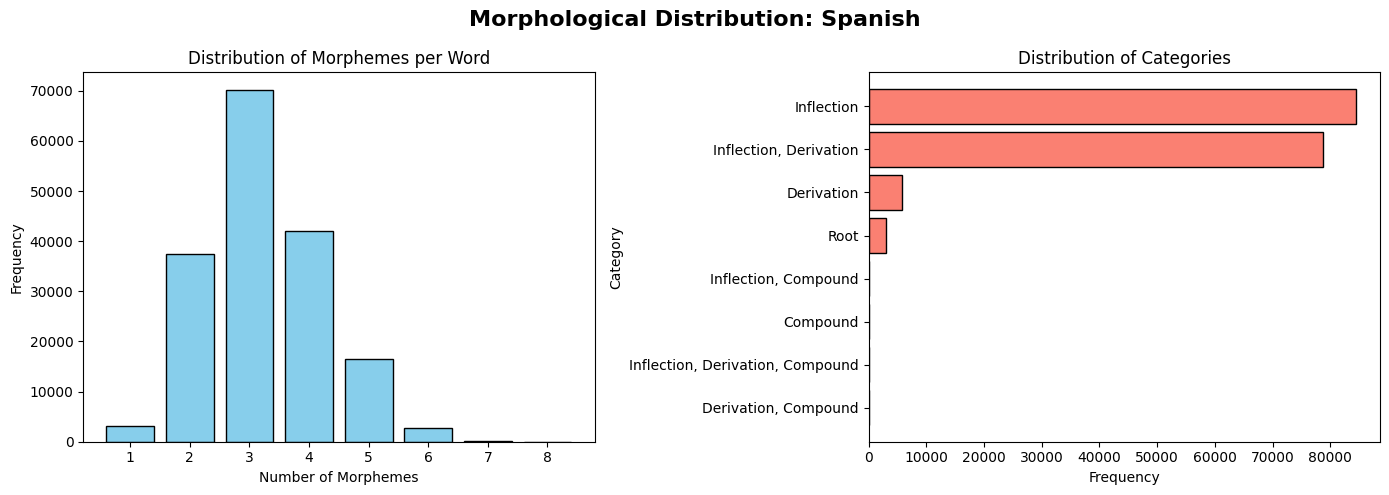

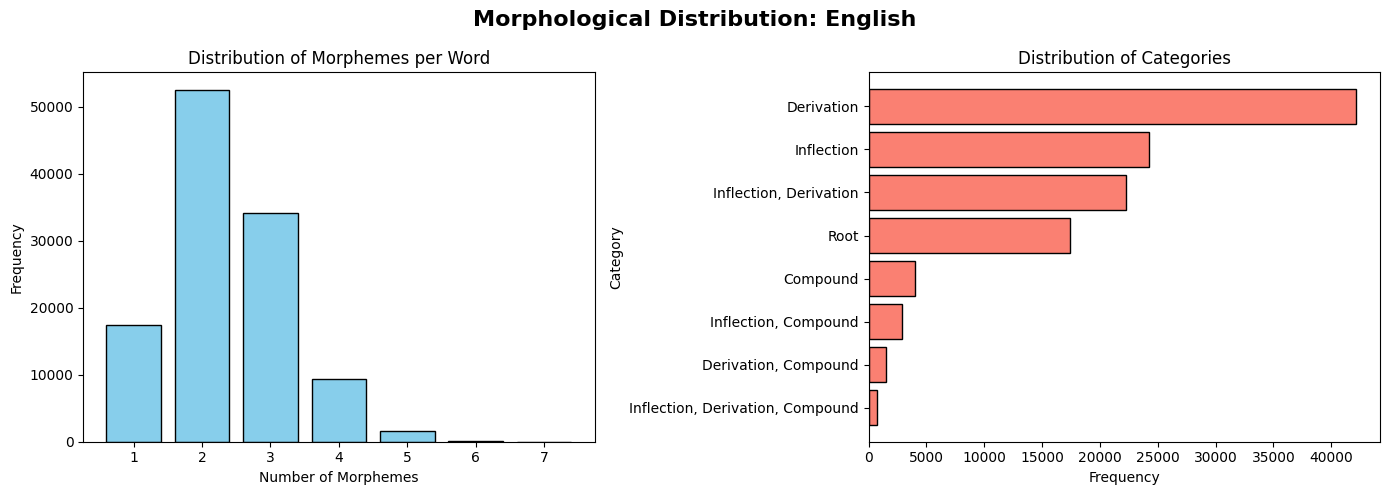

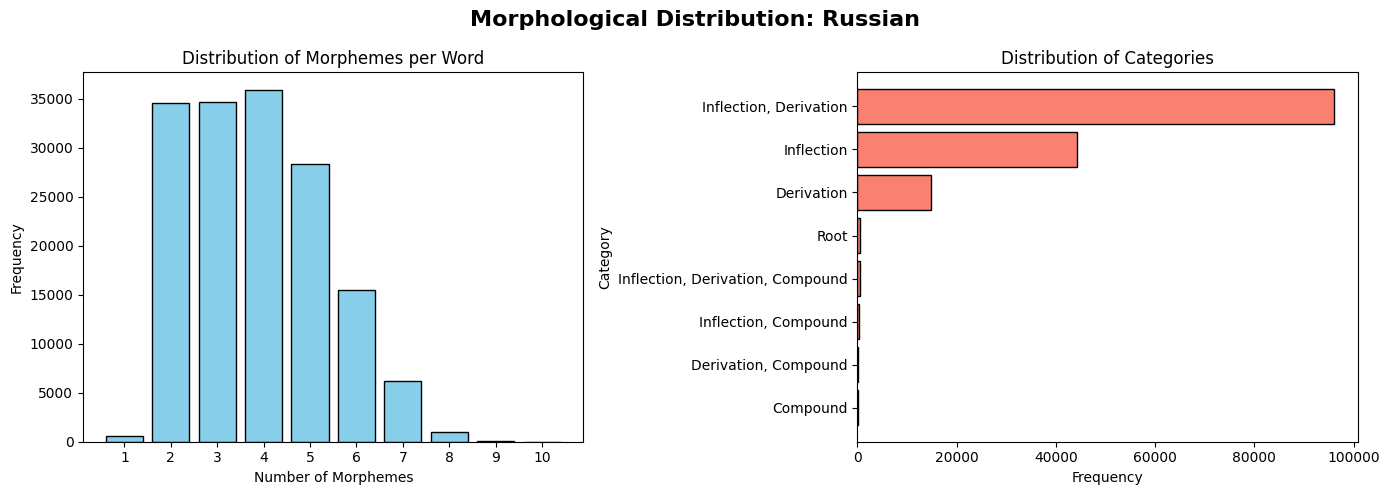

In [41]:
languages_data = {
    "Spanish": spa_df,
    "English": eng_df,
    "Russian": rus_df
}

# Iterate over each language and its corresponding DataFrame
for lang_name, df in languages_data.items():
    # Set up a figure with 1 row and 2 columns
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    fig.suptitle(f'Morphological Distribution: {lang_name}', fontsize=16, fontweight='bold')
    
    # --- Subplot 1: Distribution of morphemes per word (morph_count) ---
    morph_counts = df['morph_count'].value_counts().sort_index()
    axes[0].bar(morph_counts.index, morph_counts.values, color='skyblue', edgecolor='black')
    axes[0].set_title('Distribution of Morphemes per Word')
    axes[0].set_xlabel('Number of Morphemes')
    axes[0].set_ylabel('Frequency')
    # Force X-axis to only show integer ticks
    axes[0].set_xticks(morph_counts.index)
    
    # --- Subplot 2: Distribution of Categories ---
    # We replace category codes using the CATEGORIES mapping you defined earlier
    mapped_categories = df['category'].replace(CATEGORIES)
    cat_counts = mapped_categories.value_counts()
    
    # Plotting horizontal bars for better readability of the labels
    axes[1].barh(cat_counts.index, cat_counts.values, color='salmon', edgecolor='black')
    axes[1].set_title('Distribution of Categories')
    axes[1].set_xlabel('Frequency')
    axes[1].set_ylabel('Category')
    axes[1].invert_yaxis()  # Highest frequency at the top
    
    # Adjust layout so labels don't overlap
    plt.tight_layout()
    plt.show()


### 4 .Conclusiones

La diferencia de radio no es significativa, entre las tres lenguas. Por lo que el deducir el comportamiento de una a partir de ello no es suficiente, del mismo modo, podemos ver que existen diferencias significativas en sus indices de derivación y flexión, a pesar de que en el inglés se mantienen morfemas con mayor distribución de derivación y flexión por sí mismos, en el ruso y el español podemos ver mayor distribución en morfemas compuestos, con mayor número de morfemas por palabra. Ninguna de estas lenguas son mayormente aglutinantes o aislantes, pero de acuerdo a la longitud de los morfemas se puede decir que:

- **Más aglutinante:**  Ruso
- **Más aislante:**  Inglés

## Extra

Lo que uno tiene que hacer por tardarse en entregar :p

Vamos a importar el CRFs

In [44]:
# Descargando el corpus cess_esp
nltk.download('cess_esp')

[nltk_data] Downloading package cess_esp to
[nltk_data]     /Users/toporaku/nltk_data...
[nltk_data]   Unzipping corpora/cess_esp.zip.


True

In [45]:
# Cargando oraciones
corpora = cess_esp.tagged_sents()

In [46]:
def get_tags_map() -> dict:
    """sauce https://gist.github.com/vitojph/39c52c709a9aff2d1d24588aba7f8155/
    """
    tags_raw = r.get(
        "https://gist.githubusercontent.com/vitojph/39c52c709a9aff2d1d24588aba7f8155/raw/af2d83bc4c2a7e2e6dbb01bd0a10a23a3a21a551/universal_tagset-ES.map"
    ).text.split("\n")
    tags_map = {line.split("\t")[0].lower(): line.split("\t")[1] for line in tags_raw}
    return tags_map


def map_tag(tag: str, tags_map=get_tags_map()) -> str:
    if tags_map.get(tag.lower()) == ".":
        return "PUNCT"
    return tags_map.get(tag.lower(), "N/F")


def parse_tags(corpora: list[list[tuple]]) -> list[list[tuple]]:
    result = []
    for sentence in corpora:
        result.append([(word, map_tag(tag)) for word, tag in sentence])
    return result

In [47]:
corpora = parse_tags(corpora)

In [48]:
def word_to_features(sent, i):
    word = sent[i][0]
    features = {
        "word.lower()": word.lower(),
        "word[-3:]": word[-3:],
        "word[-2:]": word[-2:],
    }
    if i > 0:
        prev_word = sent[i - 1][0]
        features.update(
            {
                "prev_word.lower()": prev_word.lower(),
            }
        )
    else:
        # Beginning of sentence
        features["BOS"] = True
    return features


# Extract features and labels
def sent_to_features(sent) -> list:
    return [word_to_features(sent, i) for i in range(len(sent))]


def sent_to_labels(sent) -> list:
    return [label for token, label in sent]

In [49]:
# Preparando datos para el CRF
X = [sent_to_features(sent) for sent in corpora]
y = [sent_to_labels(sent) for sent in corpora]

In [50]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
# Initialize and train the CRF tagger: https://sklearn-crfsuite.readthedocs.io/en/latest/api.html
crf = CRF(
    algorithm="lbfgs",
    c2=0.001,
    max_iterations=10,
    verbose=True,
)
try:
    crf.fit(X_train, y_train)
except AttributeError as e:
    print(e)

loading training data to CRFsuite: 100%|██████████| 4824/4824 [00:00<00:00, 17184.44it/s]



Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 0
0....1....2....3....4....5....6....7....8....9....10
Number of features: 64610
Seconds required: 0.094

L-BFGS optimization
c1: 0.000000
c2: 0.001000
num_memories: 6
max_iterations: 10
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

Iter 1   time=0.10  loss=212079.86 active=64610 feature_norm=5.00
Iter 2   time=0.04  loss=143141.29 active=64610 feature_norm=10.50
Iter 3   time=0.04  loss=112380.00 active=64610 feature_norm=15.10
Iter 4   time=0.04  loss=97209.12 active=64610 feature_norm=17.37
Iter 5   time=0.04  loss=79551.54 active=64610 feature_norm=22.97
Iter 6   time=0.03  loss=70466.40 active=64610 feature_norm=29.44
Iter 7   time=0.04  loss=63740.86 active=64610 feature_norm=33.41
Iter 8   time=0.04  loss=56958.48 active=64610 feature_norm=40.80
Iter 9   time=0.04  loss=53006.59 active=64610 feature_norm=48.05
Iter

In [52]:
y_pred = crf.predict(X_test)

# Flatten the true and predicted labels
y_test_flat = [label for sent_labels in y_test for label in sent_labels]
y_pred_flat = [label for sent_labels in y_pred for label in sent_labels]

# Evaluate the model
report = classification_report(y_true=y_test_flat, y_pred=y_pred_flat)
rprint(report)

/Users/toporaku/code/lincom/cl-2026-2-lab/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/toporaku/code/lincom/cl-2026-2-lab/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/toporaku/code/lincom/cl-2026-2-lab/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

precision    recall  f1-score   support

         ADJ       0.63      0.67      0.65      2675
         ADP       0.98      0.99      0.98      6577
         ADV       0.88      0.66      0.75      1473
        CONJ       0.91      0.89      0.90      2149
         DET       0.95      0.94      0.95      5563
        NOUN       0.81      0.88      0.85      9005
         NUM       0.49      0.28      0.36       400
        PRON       0.81      0.72      0.76      1705
       PUNCT       1.00      0.99      0.99      4820
        VERB       0.90      0.88      0.89      4505
           X       0.00      0.00      0.00         4

    accuracy                           0.89     38876
   macro avg       0.76      0.72      0.73     38876
weighted avg       0.89      0.89      0.88     38876

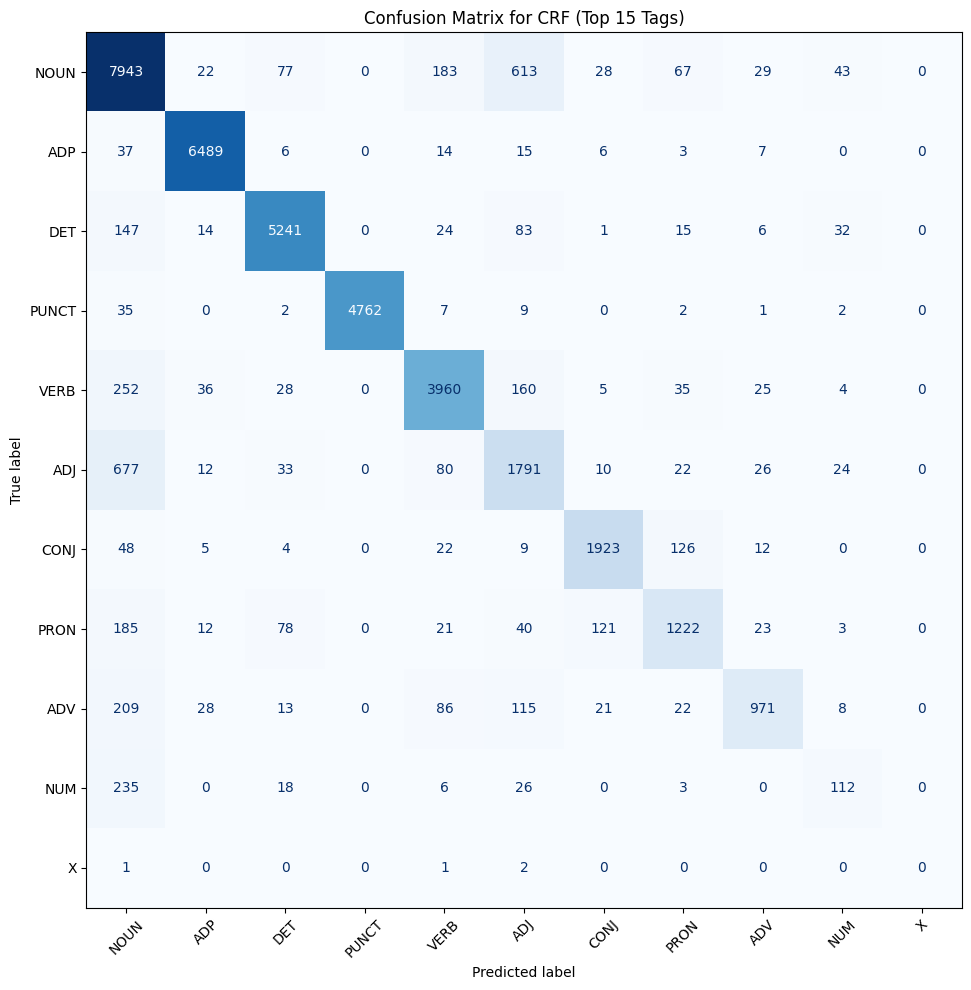

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Flatten the true and predicted nested lists
y_test_flat = [label for sentence in y_test for label in sentence]
y_pred_flat = [label for sentence in y_pred for label in sentence]

# 2. Get the top N most frequent tags in the test set
N = 15
top_tags = [tag for tag, count in Counter(y_test_flat).most_common(N)]

# 3. Generate the confusion matrix targeting ONLY those top tags
cm = confusion_matrix(y_test_flat, y_pred_flat, labels=top_tags)

# 4. Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_tags)

disp.plot(cmap='Blues', ax=ax, xticks_rotation=45, colorbar=False)

plt.title(f"Confusion Matrix for CRF")
plt.tight_layout()
plt.show()


### Observaciones
Podemos observar que, es común que nombres y adjetivos se confunde de una forma relativamente proporcional, dado que puede ser ambos, así mismo pasa con los verbos, esto en efecto puede relacionarse a ambigüedad léxica dado que en el español tenemos múltiples maneras de asociar a una única palabra, además, al estandarizar las palabras se pueden perder propiedades significativas, así como los morfemas que pueden tener una longitud más prolongada para caracterizar distintos elementos del léxico.

Para mejorar el modelo, necesitamos tres elementos clave:
1. Considerar el contexto de la palabra siguiente junto con la palabra anterior para poder determinar mejor la palabra.
2. Mejorar la forma en que se carga la entrada, separando mayusculas de minusculas, asi como la consideración por prefijos y sufijos adecuados.